In [126]:
# # Uninstall scikit-learn-extra which is incompatible with current NumPy
# !pip uninstall -y scikit-learn-extra
# # # Install pyclustering as an alternative for KMedoids
# !pip install pyclustering

# !pip install rapidfuzz

In [127]:
#@title Import Library
import numpy as np
import pandas as pd
import geopandas as gpd

# create a geometric point object from latitude and longitude coordinates
from shapely.geometry import Point

# Merge gadm DIBI kabupaten code
from rapidfuzz import process, fuzz
import re

# Data Plot
from matplotlib import pyplot as plt
import seaborn as sns
import random
import statsmodels.api as sm
import scipy.stats as stats

# Normalisasi data
from sklearn.preprocessing import MinMaxScaler

# Data Split
from sklearn.model_selection import train_test_split

# Import KMedoids from pyclustering (low-level) and prefer a higher-level estimator when available
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric


# Correctness predict
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# Collect/Merge Data

## Read Data

### Analyzing data

In [128]:
def load_data():
    bmkg_raw = pd.read_csv("../data/raw/bmkg_raw.csv")
    dibi_raw = pd.read_csv("../data/raw/dibi_raw.csv")
    gadm_raw = gpd.read_file("../data/raw/gadm41_IDN_2.json")
    
    return bmkg_raw, dibi_raw, gadm_raw

In [129]:
#@title Data Quality Assessment Function
def assess_data_quality(df, dataset_name):
    """
    Melakukan assessment menyeluruh terhadap kualitas data
    
    Parameters:
    - df: pandas DataFrame
    - dataset_name: nama dataset untuk laporan
    """
    print(f"\n{'='*70}")
    print(f"DATA QUALITY ASSESSMENT: {dataset_name}")
    print(f"{'='*70}\n")
    
    # 1. Dataset Shape
    print(f" Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # 2. Data Types
    print(f"\n Data Types:")
    print(df.dtypes)
    
    # 3. Missing Values Analysis
    print(f"\n Missing Values Analysis:")
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
    })
    missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    
    if len(missing_data) == 0:
        print(" Tidak ada missing values!")
    else:
        print(missing_data.to_string(index=False))
    
    # 4. Duplicate Rows
    duplicates = df.duplicated().sum()
    print(f"\n Duplicate Rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")
    
    # 5. Numerical Columns Statistics
    print(f"\n Numerical Columns Statistics:")
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        stats_df = df[numerical_cols].describe().T
        print(stats_df)
    else:
        print("Tidak ada kolom numerik")
    
    # 6. Outliers Detection (untuk kolom numerik)
    if len(numerical_cols) > 0:
        print(f"\n  Outlier Detection (IQR method):")
        outlier_summary = {}
        for col in numerical_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
            outlier_summary[col] = outliers
        
        outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Column', 'Outlier_Count'])
        outlier_df = outlier_df[outlier_df['Outlier_Count'] > 0]
        if len(outlier_df) > 0:
            print(outlier_df.to_string(index=False))
        else:
            print(" Tidak ada outliers terdeteksi!")
    
    # 7. Categorical Columns Summary
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"\n  Categorical Columns Summary:")
        for col in categorical_cols:
            print(f"\n  {col}:")
            print(f"    Unique Values: {df[col].nunique()}")
            print(f"    Most Common: {df[col].value_counts().head(3).to_dict()}")
    
    print(f"\n{'='*70}\n")


In [130]:
#@title Execute Data Quality Assessment
# Load raw data
bmkg_raw, dibi_raw, gadm_raw = load_data()

# Assess quality of each dataset
assess_data_quality(bmkg_raw, "BMKG (Earthquake Data)")
assess_data_quality(dibi_raw, "DIBI (Disaster Impact Data)")
assess_data_quality(gadm_raw, "GADM (Geographic/Administrative Data)")



DATA QUALITY ASSESSMENT: BMKG (Earthquake Data)

 Dataset Shape: 123577 rows × 11 columns

 Data Types:
event_id        object
date_time       object
latitude       float64
longitude      float64
magnitude      float64
mag_type        object
depth_km       float64
phase_count    float64
azimuth_gap    float64
location        object
agency          object
dtype: object

 Missing Values Analysis:
     Column  Missing_Count  Missing_Percentage
     agency           3050                2.47
   location            597                0.48
   event_id            572                0.46
   latitude            572                0.46
  date_time            572                0.46
  longitude            572                0.46
  magnitude            572                0.46
   depth_km            572                0.46
   mag_type            572                0.46
azimuth_gap            572                0.46
phase_count            572                0.46

 Duplicate Rows: 570 (0.46%)

 Numer

C:\Users\angelica\AppData\Local\Temp\ipykernel_33724\3778982114.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\angel\1_PA\backend-fastapi\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


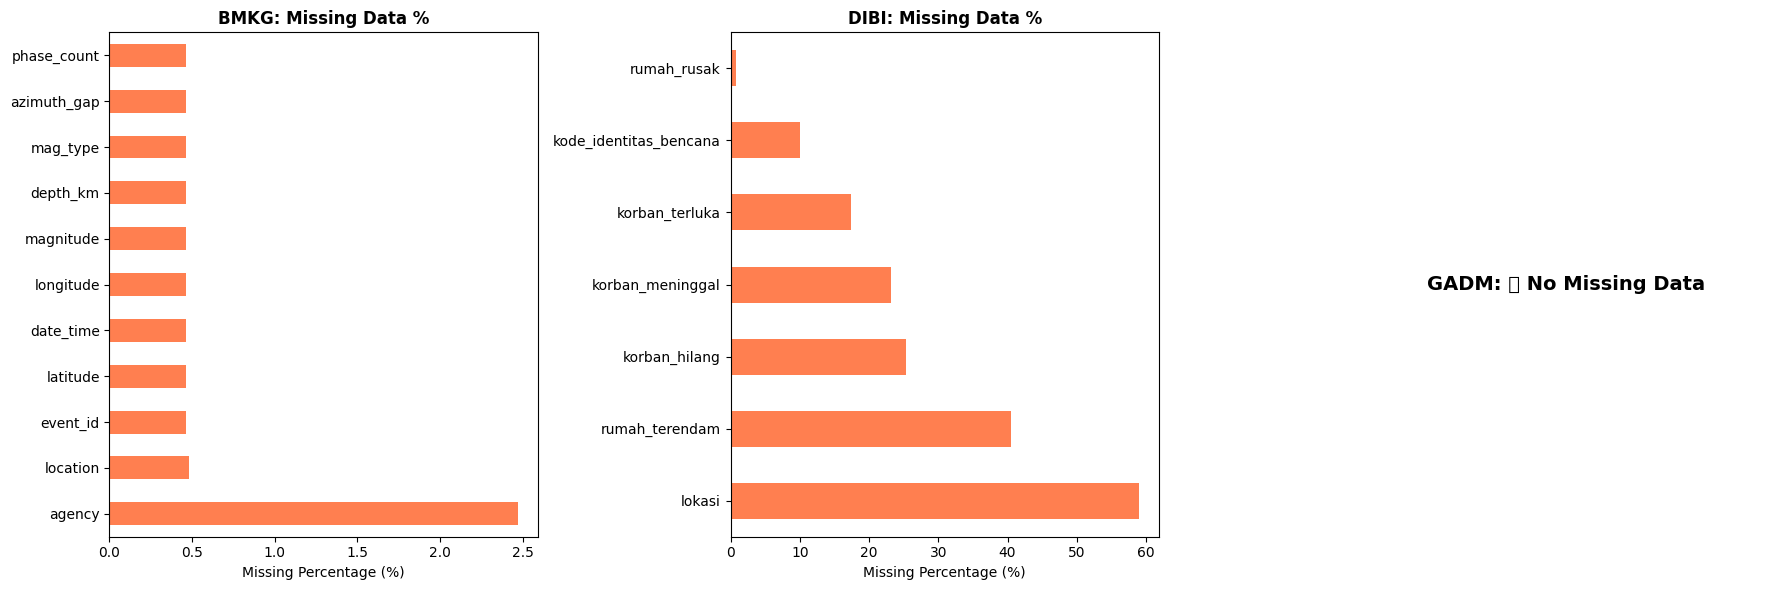


 BMKG - Numerical Columns Distribution:


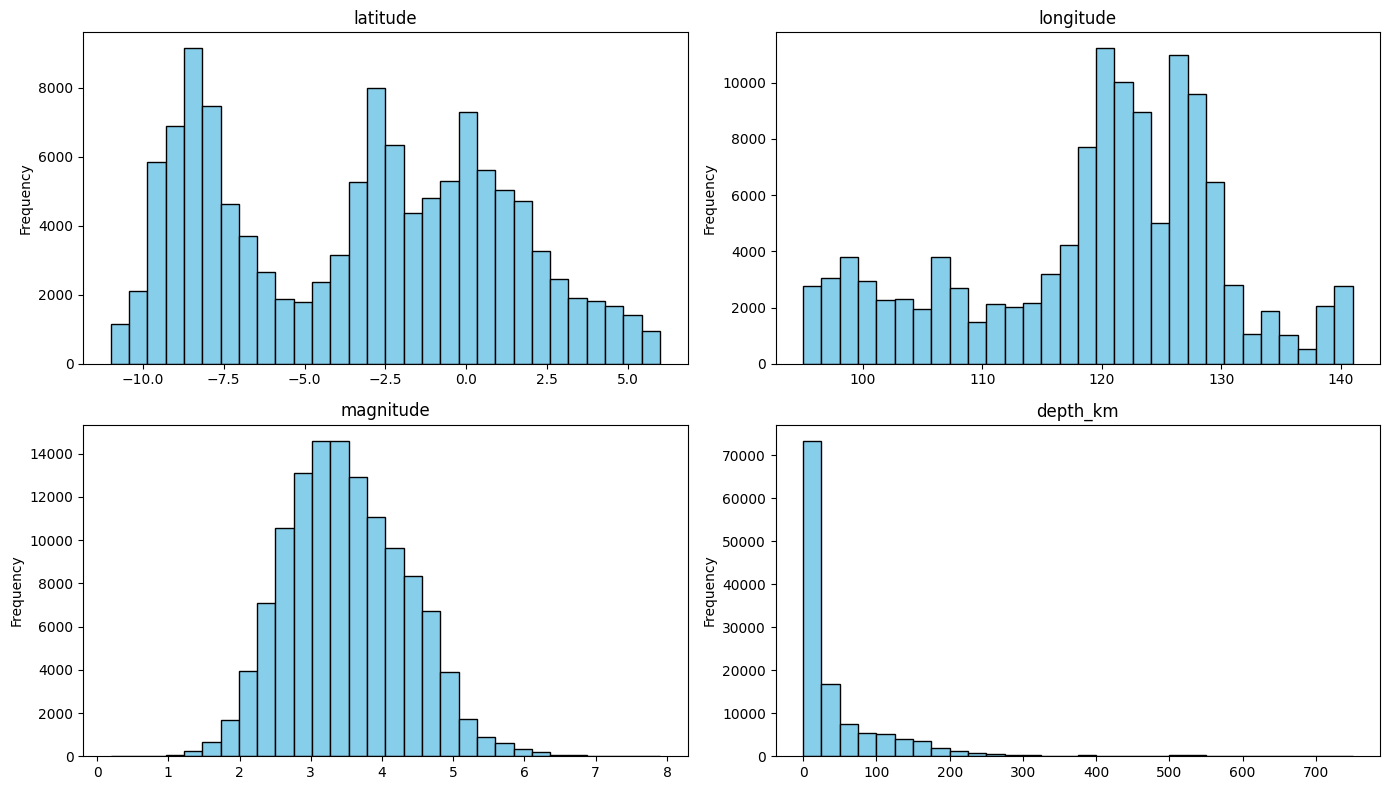


 DIBI - Numerical Columns Distribution:


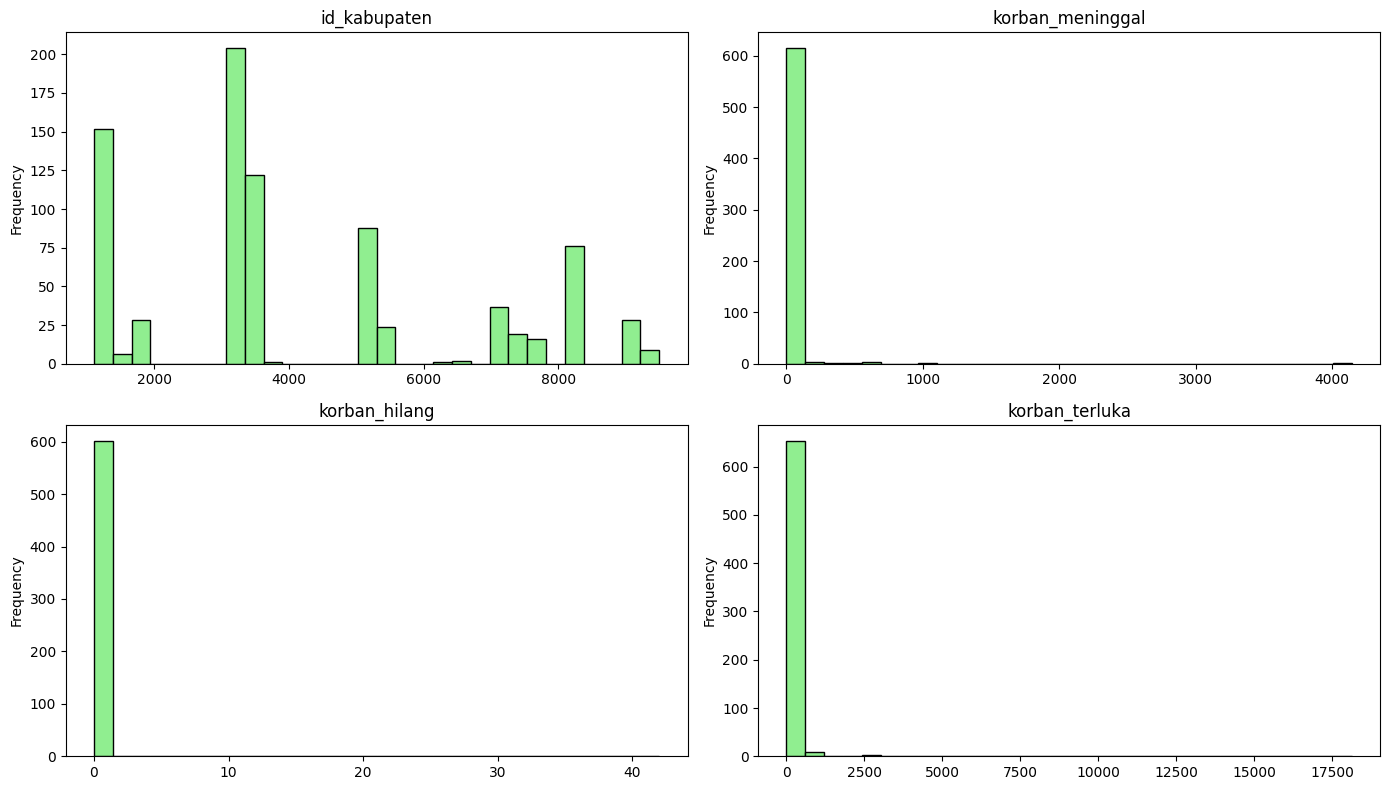

In [131]:
#@title Visualisasi Missing Data & Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Missing Data untuk setiap dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [("BMKG", bmkg_raw), ("DIBI", dibi_raw), ("GADM", gadm_raw)]

for idx, (name, df) in enumerate(datasets):
    # Hitung missing percentage
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    
    if len(missing_pct) > 0:
        missing_pct.plot(kind='barh', ax=axes[idx], color='coral')
        axes[idx].set_title(f'{name}: Missing Data %', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Missing Percentage (%)')
    else:
        axes[idx].text(0.5, 0.5, f'{name}: ✅ No Missing Data', 
                      ha='center', va='center', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Visualisasi distribusi untuk kolom numerik BMKG
print("\n BMKG - Numerical Columns Distribution:")
numerical_bmkg = bmkg_raw.select_dtypes(include=[np.number]).columns
if len(numerical_bmkg) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    for idx, col in enumerate(numerical_bmkg[:4]):
        axes[idx].hist(bmkg_raw[col].dropna(), bins=30, edgecolor='black', color='skyblue')
        axes[idx].set_title(f'{col}')
        axes[idx].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Visualisasi distribusi untuk kolom numerik DIBI
print("\n DIBI - Numerical Columns Distribution:")
numerical_dibi = dibi_raw.select_dtypes(include=[np.number]).columns
if len(numerical_dibi) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    for idx, col in enumerate(numerical_dibi[:4]):
        axes[idx].hist(dibi_raw[col].dropna(), bins=30, edgecolor='black', color='lightgreen')
        axes[idx].set_title(f'{col}')
        axes[idx].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()


In [132]:
#@title Clean Duplicates in BMKG
# drop duplicates based on all columns (you may adjust subset if needed)
initial_count = len(bmkg_raw)
bmkg_raw = bmkg_raw.drop_duplicates()
cleaned_count = len(bmkg_raw)
print(f"BMKG duplicates removed: {initial_count - cleaned_count} rows (from {initial_count} to {cleaned_count})")

# re-run assessment to see effect if desired
assess_data_quality(bmkg_raw, "BMKG after duplicate removal")

BMKG duplicates removed: 570 rows (from 123577 to 123007)

DATA QUALITY ASSESSMENT: BMKG after duplicate removal

 Dataset Shape: 123007 rows × 11 columns

 Data Types:
event_id        object
date_time       object
latitude       float64
longitude      float64
magnitude      float64
mag_type        object
depth_km       float64
phase_count    float64
azimuth_gap    float64
location        object
agency          object
dtype: object

 Missing Values Analysis:
     Column  Missing_Count  Missing_Percentage
     agency           2480                2.02
   location             27                0.02
   event_id              2                0.00
   latitude              2                0.00
  date_time              2                0.00
  longitude              2                0.00
  magnitude              2                0.00
   depth_km              2                0.00
   mag_type              2                0.00
azimuth_gap              2                0.00
phase_count         

### Func Data GADM Polygon Wilayah Kab/Kota

In [133]:
#@title Data Polygon Wilayah Kab/Kota

def prepare_gadm(gadm):
    gadm = gadm.to_crs("EPSG:4326")

    gadm["luas_wilayah_km2"] = gadm.to_crs(epsg=3395).geometry.area / 10**6

    gadm = gadm.rename(columns={
        "GID_2": "id_kabupaten",
        "NAME_2": "nama_kabupaten"
    })

    return gadm[["id_kabupaten", "nama_kabupaten", "luas_wilayah_km2", "geometry"]]

### Func BMKG Agregasi per kabupaten

In [134]:
#@title Proses BMKG Agregasi per kabupaten
def process_bmkg(bmkg, gadm):

    # convert longitude/latitude from raw BMKG data into geometry points
    bmkg["geometry"] = bmkg.apply(
        lambda r: Point(r["longitude"], r["latitude"]), axis=1
    )

    bmkg_gdf = gpd.GeoDataFrame(bmkg, geometry="geometry", crs="EPSG:4326")

    bmkg_join = gpd.sjoin(
        bmkg_gdf,
        gadm[["id_kabupaten", "geometry"]],
        how="left",
        predicate="within"
    )

    bmkg_agg = (
        bmkg_join.groupby("id_kabupaten")
        .agg(
            frekuensi_gempa=("magnitude", "count"),
            mag_max=("magnitude", "max"),
            mag_mean=("magnitude", "mean"),
            depth_mean=("depth_km", "mean"),
        )
        .reset_index()
    )

    return bmkg_agg

## DIBI Process

### Func Match Code Kab DIBI w/ GADM

In [135]:
# Redefine map_dibi_to_gadm with preprocessing (already done, but re-include for completeness)
def map_dibi_to_gadm(dibi_raw, gadm, threshold=75):

    # Preprocess GADM names
    gadm_names_original = gadm["nama_kabupaten"].unique()
    gadm_names_processed = [
        name.lower().replace("kabupaten", "").replace("kota", "").strip()
        for name in gadm_names_original
    ]
    gadm_name_to_processed = dict(zip(gadm_names_processed, gadm_names_original))

    # Preprocess DIBI names
    dibi_names = dibi_raw["kabupaten"].dropna().unique()
    mapping = {}

    for original_dibi_name in dibi_names:
        processed_dibi_name = original_dibi_name.lower().replace("kota", "").replace("kabupaten", "").strip()

        # Try to find a match using the processed names
        match, score, _ = process.extractOne(processed_dibi_name, gadm_names_processed, scorer=fuzz.WRatio)

        if score >= threshold:
            mapping[original_dibi_name] = gadm_name_to_processed[match] # Map back to original GADM name
        else:
            mapping[original_dibi_name] = None

    return pd.DataFrame(mapping.items(), columns=["kabupaten", "nama_kabupaten"])

### Func DIBI Aggregation

In [136]:
#@title Agregasi DIBI

# Redefine process_dibi to correctly handle id_kabupaten_y
def process_dibi(dibi_raw, gadm):

    # hitung total korban
    dibi_raw["korban_total"] = (
        dibi_raw["korban_meninggal"].fillna(0)
        + dibi_raw["korban_hilang"].fillna(0)
        + dibi_raw["korban_terluka"].fillna(0)
    )
    
    # mapping nama kabupaten
    mapping_df = map_dibi_to_gadm(dibi_raw, gadm)

    dibi = dibi_raw.merge(mapping_df, on="kabupaten", how="left")
    dibi = dibi.merge(
        gadm[["id_kabupaten", "nama_kabupaten"]],
        on="nama_kabupaten",
        how="left",
        suffixes=('_original', '_gadm')
    )

    # The GADM id_kabupaten is now in 'id_kabupaten_gadm'. Rename it to 'id_kabupaten' for aggregation.
    if 'id_kabupaten_gadm' in dibi.columns:
        dibi = dibi.rename(columns={'id_kabupaten_gadm': 'id_kabupaten'})
    # Ensure 'id_kabupaten' exists and is the GADM one, handling cases where there might not have been a clash
    elif 'id_kabupaten' not in dibi.columns:
        dibi['id_kabupaten'] = dibi['id_kabupaten_original'] if 'id_kabupaten_original' in dibi.columns else pd.NA

    # If the dataframe is empty after all merges, the groupby will be empty as well.
    # Return an empty DataFrame with the expected columns if dibi is empty.
    if dibi.empty or dibi['id_kabupaten'].isnull().all():
        return pd.DataFrame(columns=['id_kabupaten', 'korban_total', 'rumah_rusak_total', 'fasum_rusak_total'])

    # agregasi
    dibi_agg = (
        dibi.groupby("id_kabupaten", dropna=True) # Drop rows where id_kabupaten is NA before grouping
        .agg(
            korban_total=("korban_total", "sum"),
            rumah_rusak_total=("rumah_rusak", "sum"),
            fasum_rusak_total=("fasum_rusak", "sum"),
        )
        .reset_index()
    )

    print(dibi_agg.head())
    return dibi_agg


In [137]:
#@title Merge All data

def merge_all(gadm, bmkg_agg, dibi_agg):

    # initial_merged_features_df: DataFrame containing raw, merged features from GADM, BMKG, and DIBI.
    initial_merged_features_df = (
        gadm.merge(bmkg_agg, on="id_kabupaten", how="left")
            .merge(dibi_agg, on="id_kabupaten", how="left")
    )

    initial_merged_features_df = initial_merged_features_df.fillna(0)

    return initial_merged_features_df.drop(columns="geometry")

In [138]:
# Redefine cleaning function to use the updated process_dibi
def cleaning():
    # bmkg_raw_df, dibi_raw_df, gadm_raw_df: Original raw datasets.
    bmkg_raw_df, dibi_raw_df, gadm_raw_df = load_data()

    # --- additional cleaning on BMKG before aggregation ---
    orig_len = len(bmkg_raw_df)
    bmkg_raw_df = bmkg_raw_df.drop_duplicates()
    bmkg_raw_df = bmkg_raw_df.dropna(subset=['latitude', 'longitude'])
    cleaned_len = len(bmkg_raw_df)
    print(f"Cleaned BMKG rows: {orig_len} -> {cleaned_len} (duplicates/missing coords removed)")

    # gadm_processed_df: GADM data after initial processing (e.g., CRS conversion, column renaming).
    gadm_processed_df = prepare_gadm(gadm_raw_df)

    # bmkg_aggregated_df, dibi_aggregated_df: Data aggregated by kabupaten.
    bmkg_aggregated_df = process_bmkg(bmkg_raw_df, gadm_processed_df)
    dibi_aggregated_df = process_dibi(dibi_raw_df, gadm_processed_df)

    print("\nBMKG Aggregated Data Head:")
    display(bmkg_aggregated_df.head())
    print("\nDIBI Aggregated Data Head:")
    display(dibi_aggregated_df.head())

    # raw_features_df: Merged dataframe containing all features before normalization and clustering.
    raw_features_df = merge_all(gadm_processed_df, bmkg_aggregated_df, dibi_aggregated_df)

    # raw_features_df.to_csv("/content/drive/MyDrive/dataset_PA/fitur_risiko_ex_1.csv", index=False)
    return raw_features_df

In [139]:
# raw_features_df: DataFrame containing all initial features after cleaning and merging.
raw_features_df = cleaning()

print("\nFitur DataFrame after improved DIBI mapping:")
display(raw_features_df.head())

print("\nDescriptive statistics for DIBI-related columns:")
display(raw_features_df[['korban_total', 'rumah_rusak_total', 'fasum_rusak_total']].describe())

Cleaned BMKG rows: 123577 -> 123005 (duplicates/missing coords removed)
  id_kabupaten  korban_total  rumah_rusak_total  fasum_rusak_total
0   IDN.1.10_1           0.0               57.0                  0
1   IDN.1.13_1         122.0             5168.0                429
2   IDN.1.14_1         272.0              836.0                166
3   IDN.1.15_1           0.0               26.0                  2
4   IDN.1.16_1           0.0               19.0                  0

BMKG Aggregated Data Head:


,id_kabupaten,frekuensi_gempa,mag_max,mag_mean,depth_mean
0,IDN.1.10_1,90,4.936356,2.675589,16.611111
1,IDN.1.11_1,15,4.280014,3.039269,22.533333
2,IDN.1.12_1,1,3.189475,3.189475,10.000000
3,IDN.1.13_1,92,4.872642,2.793265,10.282609
4,IDN.1.14_1,27,4.702885,3.210301,33.703704



DIBI Aggregated Data Head:


,id_kabupaten,korban_total,rumah_rusak_total,fasum_rusak_total
0,IDN.1.10_1,0.0,57.0,0
1,IDN.1.13_1,122.0,5168.0,429
2,IDN.1.14_1,272.0,836.0,166
3,IDN.1.15_1,0.0,26.0,2
4,IDN.1.16_1,0.0,19.0,0



Fitur DataFrame after improved DIBI mapping:


,id_kabupaten,nama_kabupaten,luas_wilayah_km2,frekuensi_gempa,mag_max,mag_mean,depth_mean,korban_total,rumah_rusak_total,fasum_rusak_total
0,IDN.1.2_1,AcehBarat,2830.172009,318.0,5.495930,3.170380,16.088050,0.0,8.0,0.0
1,IDN.1.1_1,AcehBaratDaya,1902.538392,49.0,4.550803,3.146511,45.183673,0.0,17.0,0.0
2,IDN.1.3_1,AcehBesar,2932.706336,120.0,5.064877,3.287325,25.691667,0.0,0.0,0.0
3,IDN.1.4_1,AcehJaya,3894.489157,93.0,5.874450,3.334289,47.204301,0.0,0.0,1.0
4,IDN.1.5_1,AcehSelatan,4231.250552,138.0,5.062686,3.000998,33.391304,3.0,2717.0,324.0



Descriptive statistics for DIBI-related columns:


,korban_total,rumah_rusak_total,fasum_rusak_total
count,502.000000,502.000000,502.000000
mean,186.635458,3106.221116,111.948207
std,1332.000297,13413.917014,437.860477
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,2.000000,139.750000,13.500000
max,19172.000000,148580.000000,5160.000000


In [140]:
# generate and show mapping diagnostics
bmkg_raw_df, dibi_raw_df, gadm_raw_df = load_data()
gadm_processed_df = prepare_gadm(gadm_raw_df)
mapping_df = map_dibi_to_gadm(dibi_raw_df, gadm_processed_df)

# calculate mapping stats
total_names = mapping_df.shape[0]
unmapped_count = mapping_df['nama_kabupaten'].isna().sum()
mapped_count = total_names - unmapped_count

print('--- Mapping Summary ---')
summary_df = pd.DataFrame({
    'status': ['mapped', 'unmapped'],
    'count': [mapped_count, unmapped_count]
})
display(summary_df)

# # pie chart comparison
# plt.figure(figsize=(6,6))
# colors = ['green','red']
# plt.pie(summary_df['count'], labels=summary_df['status'], autopct='%1.1f%%', colors=colors, startangle=90)
# plt.title('Mapped vs Unmapped DIBI Kabupaten Names')
# plt.axis('equal')  # keep circle aspect
# plt.show()

# table of unmapped names for inspection
if unmapped_count > 0:
    print('--- Unmapped DIBI Kabupaten Names ---')
    display(mapping_df[mapping_df['nama_kabupaten'].isna()][['kabupaten']].head(20))

# show some examples from GADM
print('\n--- Examples of GADM Kabupaten Names  ---')
display(gadm_processed_df[['nama_kabupaten']].head(10))

--- Mapping Summary ---


,status,count
0,mapped,276
1,unmapped,2


--- Unmapped DIBI Kabupaten Names ---


,kabupaten
59,PANGANDARAN
120,PESISIR BARAT



--- Examples of GADM Kabupaten Names  ---


,nama_kabupaten
0,AcehBarat
1,AcehBaratDaya
2,AcehBesar
3,AcehJaya
4,AcehSelatan
5,AcehSingkil
6,AcehTamiang
7,AcehTengah
8,AcehTenggara
9,AcehTimur


## Heatmap Variation Data

Numeric variables used in heatmap:


,variable
0,luas_wilayah_km2
1,frekuensi_gempa
2,mag_max
3,mag_mean
4,depth_mean
5,korban_total
6,rumah_rusak_total
7,fasum_rusak_total


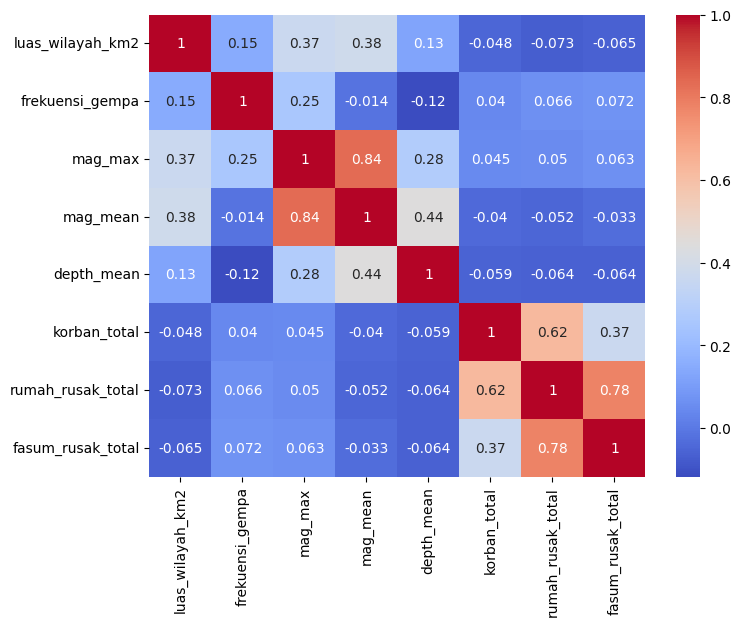

In [141]:
#@title HeatMap Variabel

# show numeric columns included in correlation
print('Numeric variables used in heatmap:')
num_cols = raw_features_df.select_dtypes(include=[np.number]).columns.tolist()
display(pd.DataFrame({'variable': num_cols}))

corr = raw_features_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [142]:
    # Inisialisasi MinMaxScaler
def normalize_data(raw_features_df):
    scaler = MinMaxScaler()

    # numerical_features_to_scale_df: DataFrame containing only numerical columns from raw_features_df, ready for scaling.
    numerical_features_to_scale_df = raw_features_df.select_dtypes(include=np.number)

    # scaled_numerical_features_array: NumPy array containing the scaled numerical features.
    scaled_numerical_features_array = scaler.fit_transform(numerical_features_to_scale_df)

    print("\nData setelah Normalisasi Min-Max:")

    # scaled_numerical_features_df: DataFrame containing the scaled numerical features with original column names.
    scaled_numerical_features_df = pd.DataFrame(scaled_numerical_features_array, columns=numerical_features_to_scale_df.columns)

    display(scaled_numerical_features_df.head())
    
    return scaled_numerical_features_df, scaler

In [143]:
# Merge the normalized data with 'id_kabupaten' and 'nama_kabupaten' from the original 'raw_features_df' DataFrame
# This assumes the order of rows is preserved during the scaling, which it is if you didn't reindex 'numerical_features_to_scale_df'

# final_processed_df: The main DataFrame containing original identifiers, scaled features, and later, clustering results and PCA components.
final_processed_df = pd.concat([
    raw_features_df[['id_kabupaten', 'nama_kabupaten']].reset_index(drop=True),
    scaled_numerical_features_df.reset_index(drop=True)
], axis=1)

print("Normalized DataFrame with Kabupaten Names:")
display(final_processed_df.head())

Normalized DataFrame with Kabupaten Names:


,id_kabupaten,nama_kabupaten,luas_wilayah_km2,frekuensi_gempa,mag_max,mag_mean,depth_mean,korban_total,rumah_rusak_total,fasum_rusak_total
0,IDN.1.2_1,AcehBarat,0.063280,0.145007,0.695494,0.528401,0.031300,0.000000,0.000054,0.000000
1,IDN.1.1_1,AcehBaratDaya,0.042475,0.022344,0.575891,0.524423,0.087906,0.000000,0.000114,0.000000
2,IDN.1.3_1,AcehBesar,0.065579,0.054720,0.640945,0.547892,0.049984,0.000000,0.000000,0.000000
3,IDN.1.4_1,AcehJaya,0.087150,0.042408,0.743394,0.555719,0.091837,0.000000,0.000000,0.000194
4,IDN.1.5_1,AcehSelatan,0.094703,0.062927,0.640668,0.500170,0.064964,0.000156,0.018286,0.062791


Now, `final_normalized_df` contains your normalized numerical features along with the `id_kabupaten` and `nama_kabupaten` columns, allowing you to link the scaled data back to its geographic location.

## Visual Inspection for Normality

Generating Histograms and Q-Q Plots for numerical features...


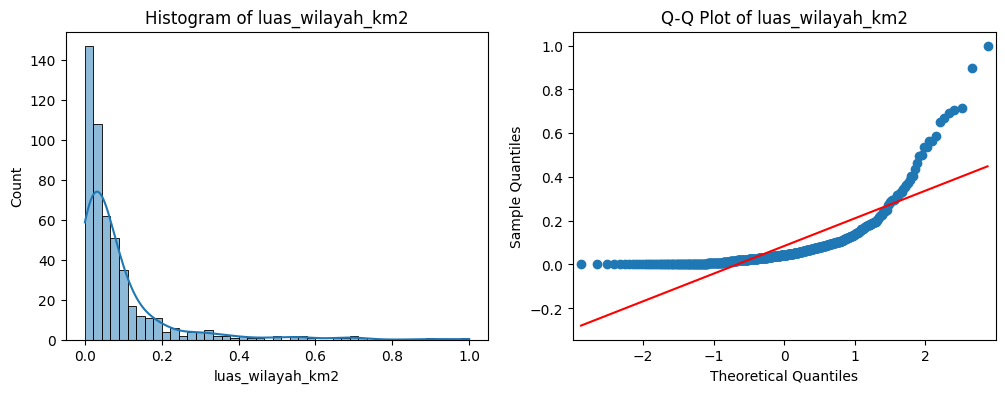

<Figure size 640x480 with 0 Axes>

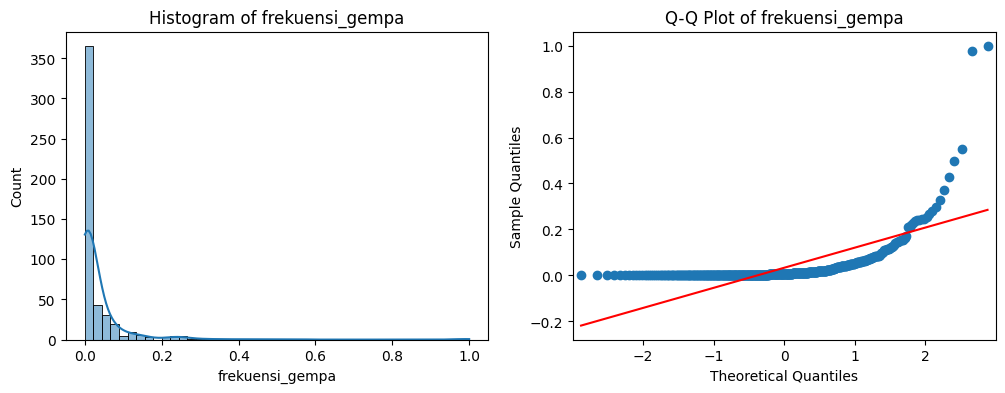

<Figure size 640x480 with 0 Axes>

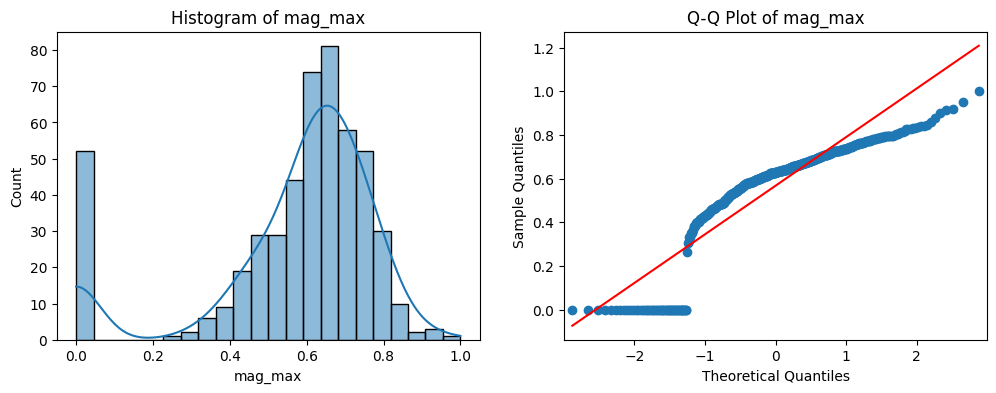

<Figure size 640x480 with 0 Axes>

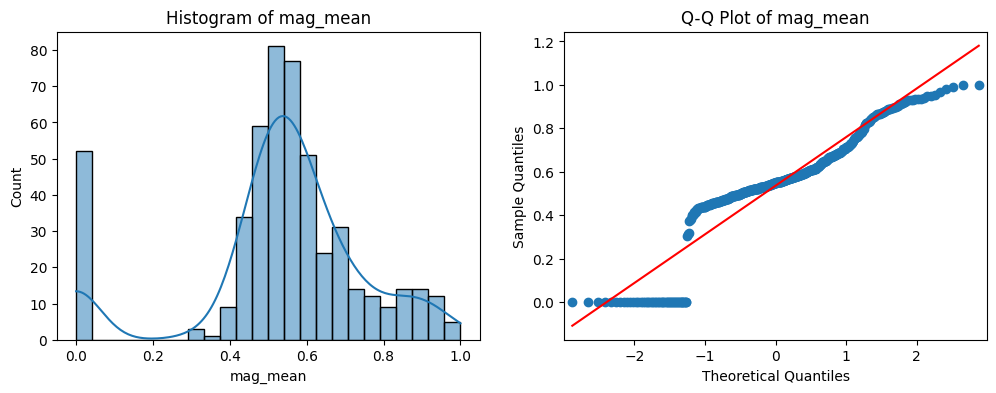

<Figure size 640x480 with 0 Axes>

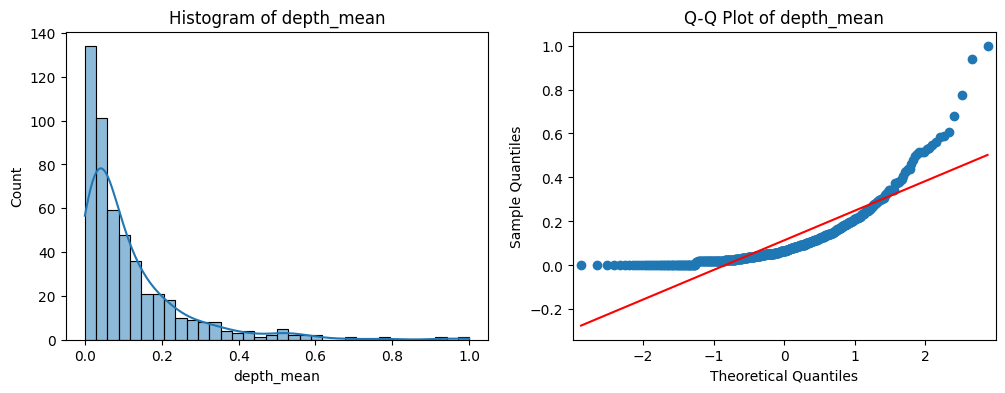

<Figure size 640x480 with 0 Axes>

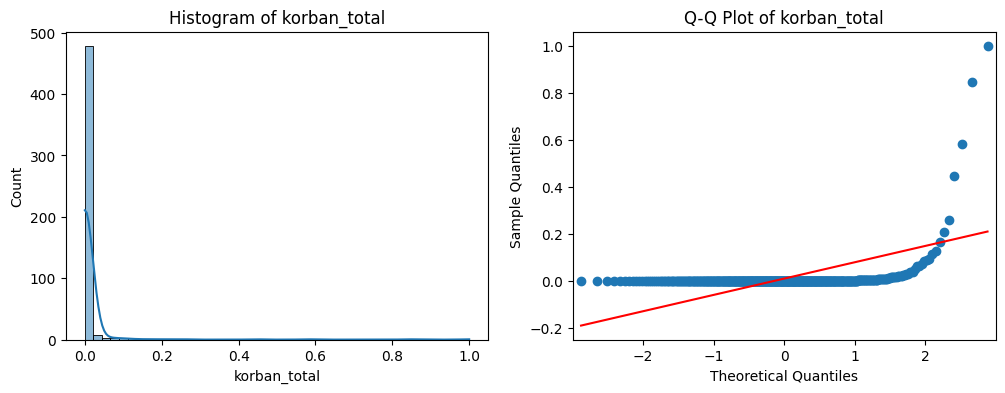

<Figure size 640x480 with 0 Axes>

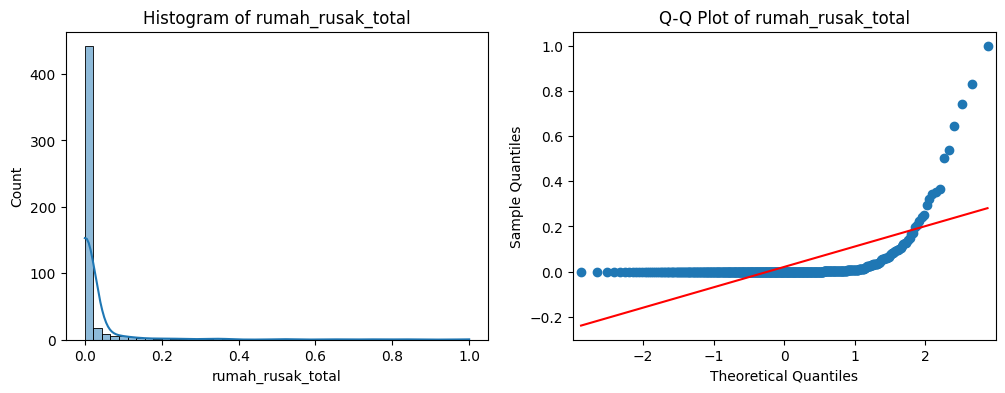

<Figure size 640x480 with 0 Axes>

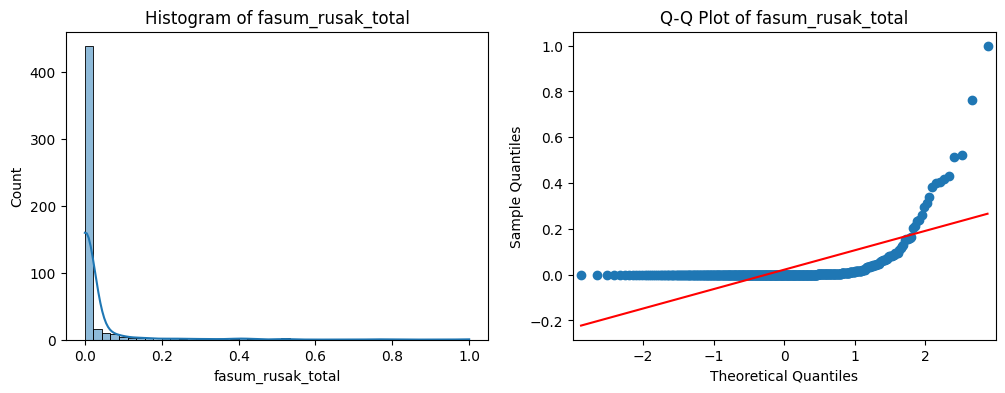

<Figure size 640x480 with 0 Axes>

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# make sure the merged/normalized dataframe exists
if 'final_processed_df' not in globals():
    raise NameError("`final_processed_df` is not defined. Run the normalization/merge cell above before executing this cell.")

# Select the numerical columns for checking normality
numerical_cols = final_processed_df.select_dtypes(include=np.number).columns

print("Generating Histograms and Q-Q Plots for numerical features...")

# Plot histograms and Q-Q plots for each numerical feature
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(final_processed_df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    # Q-Q Plot
    sm.qqplot(final_processed_df[col], line='s', ax=axes[1])

    axes[1].set_title(f'Q-Q Plot of {col}')   
    plt.show()

    plt.tight_layout()

In [145]:
# ensure the dataframe is available for clustering prep
if 'final_processed_df' not in globals():
    raise NameError("`final_processed_df` is not defined. Run the normalization/merge cell above before executing this cell.")

# clustering_input_df: DataFrame containing only numerical features, used as input for K-Medoids clustering.

clustering_input_df = final_processed_df.select_dtypes(include=np.number).copy()

display(clustering_input_df.head())

print("Data prepared for K-Medoids clustering (numerical features only):")

,luas_wilayah_km2,frekuensi_gempa,mag_max,mag_mean,depth_mean,korban_total,rumah_rusak_total,fasum_rusak_total
0,0.063280,0.145007,0.695494,0.528401,0.031300,0.000000,0.000054,0.000000
1,0.042475,0.022344,0.575891,0.524423,0.087906,0.000000,0.000114,0.000000
2,0.065579,0.054720,0.640945,0.547892,0.049984,0.000000,0.000000,0.000000
3,0.087150,0.042408,0.743394,0.555719,0.091837,0.000000,0.000000,0.000194
4,0.094703,0.062927,0.640668,0.500170,0.064964,0.000156,0.018286,0.062791


Data prepared for K-Medoids clustering (numerical features only):


**Reasoning**:
Now that the numerical features are prepared, I will use the Elbow method to find the optimal number of clusters for K-Medoids. This involves iterating through a range of possible cluster numbers, running the K-Medoids algorithm for each, and calculating the total distance to medoids (inertia) to identify the 'elbow' point.



# Modeling

#### Elbow Method

In [146]:

max_k = 10
n_init = 5   # jumlah percobaan tiap k (bisa 5–10)
inertia = []

# clustering_data_list: List of lists representation of clustering_input_df for pyclustering.
clustering_data_list = clustering_input_df.values.tolist()
metric = distance_metric(type_metric.EUCLIDEAN)

n_samples = len(clustering_data_list)

for k in range(1, max_k + 1):

    if k > n_samples:
        inertia.append(float('nan'))
        continue

    best_inertia = float('inf')

    for i in range(n_init):
        random.seed(42 + i)  # seed berbeda tiap percobaan
        initial_medoids = random.sample(range(n_samples), k)

        kmedoids_instance = kmedoids(clustering_data_list, initial_medoids, metric=metric)
        kmedoids_instance.process()

        clusters = kmedoids_instance.get_clusters()
        medoids_indices = kmedoids_instance.get_medoids()

        current_inertia = 0
        for cluster, medoid_idx in zip(clusters, medoids_indices):
            medoid = clustering_data_list[medoid_idx]
            for point_idx in cluster:
                point = clustering_data_list[point_idx]
                current_inertia += metric(point, medoid) ** 2

        best_inertia = min(best_inertia, current_inertia)

    inertia.append(best_inertia)

elbow_data = pd.DataFrame({
    'k': range(1, max_k + 1),
    'inertia': inertia
})

print(elbow_data)

    k    inertia
0   1  84.118258
1   2  46.541439
2   3  36.946788
3   4  31.935685
4   5  29.374021
5   6  24.743912
6   7  22.305280
7   8  19.918669
8   9  18.090316
9  10  17.508770


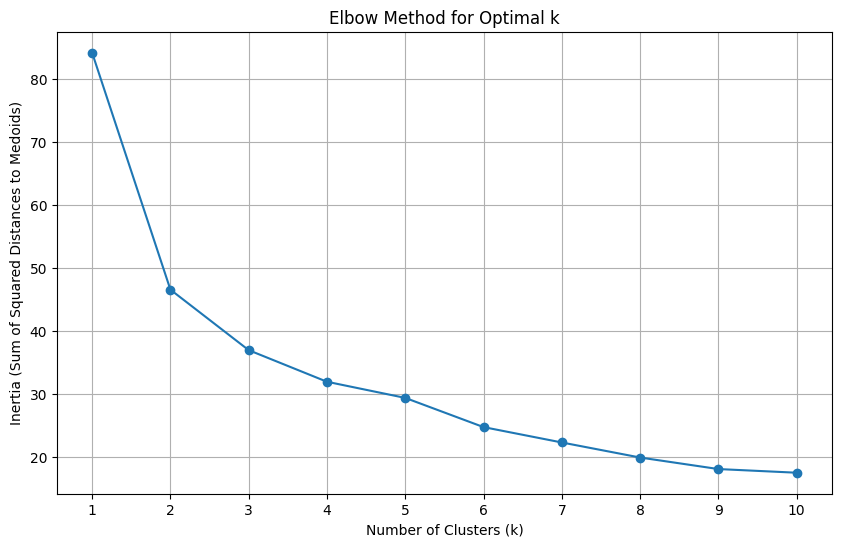

Elbow plot displayed to help determine optimal k.


In [147]:
# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(elbow_data['k'], elbow_data['inertia'], marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances to Medoids)')
plt.xticks(range(1, len(elbow_data['k']) + 1))
plt.grid(True)
plt.show()

print("Elbow plot displayed to help determine optimal k.")

#### Silhouette Score

In [148]:
import random
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, max_k + 1):   # mulai dari 2

    if k > n_samples:
        silhouette_scores.append(float('nan'))
        continue

    best_score = -1

    for i in range(n_init):
        random.seed(42 + i)
        initial_medoids = random.sample(range(n_samples), k)

        kmedoids_instance = kmedoids(clustering_data_list, initial_medoids, metric=metric)
        kmedoids_instance.process()

        clusters = kmedoids_instance.get_clusters()

        # Ubah format cluster → label
        labels = np.zeros(n_samples)
        for cluster_id, cluster in enumerate(clusters):
            for index in cluster:
                labels[index] = cluster_id
        labels = labels.astype(int)

        score = silhouette_score(clustering_input_df, labels)
        best_score = max(best_score, score)

    silhouette_scores.append(best_score)

# Simpan hasil
silhouette_data = pd.DataFrame({
    'k': range(2, max_k + 1),
    'silhouette_score': silhouette_scores
})

print(silhouette_data)

    k  silhouette_score
0   2          0.625411
1   3          0.343124
2   4          0.322654
3   5          0.296324
4   6          0.304212
5   7          0.306516
6   8          0.326533
7   9          0.315299
8  10          0.287698


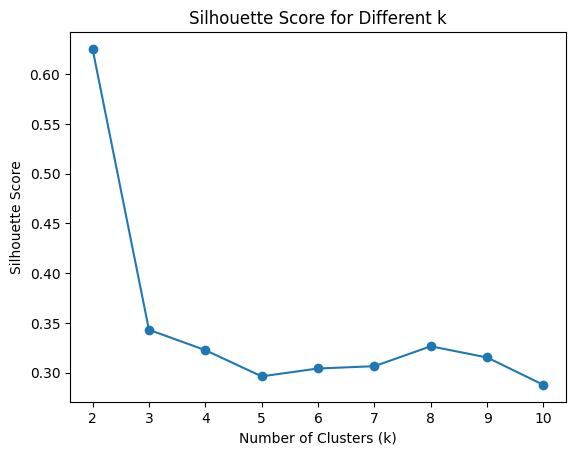

In [149]:
# Silhouette Score
plt.figure()
plt.plot(silhouette_data['k'], silhouette_data['silhouette_score'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.show()

In [150]:
best_k = silhouette_data.loc[
    silhouette_data['silhouette_score'].idxmax()
]

print("Best k based on Silhouette:")
print(best_k)

Best k based on Silhouette:
k                   2.000000
silhouette_score    0.625411
Name: 0, dtype: float64


**Reasoning**:
To visualize the results of the Elbow method and identify the optimal number of clusters (k), I will plot the inertia values against the number of clusters (k). This visual representation will help in finding the 'elbow' point where the decrease in inertia starts to slow down, suggesting a good balance between cluster cohesion and model complexity.



# KMedoid Model

## Gempa dengan KMedoids pyclustering

In [151]:
def run_clustering(final_processed_df, k=3):

    clustering_input_df = final_processed_df.select_dtypes(include=np.number)

    data_list = clustering_input_df.values.tolist()
    n_samples = len(data_list)

    random.seed(42)
    initial_medoids = random.sample(range(n_samples), k)
    metric = distance_metric(type_metric.EUCLIDEAN)

    model = kmedoids(data_list, initial_medoids, metric=metric)
    model.process()

    clusters = model.get_clusters()

    labels = np.zeros(n_samples, dtype=int)
    for cluster_id, cluster in enumerate(clusters):
        for idx in cluster:
            labels[idx] = cluster_id

    final_processed_df["cluster_label"] = labels

    cluster_characteristics_df = (
        final_processed_df
        .groupby("cluster_label")
        .mean(numeric_only=True)
    )
    

    return final_processed_df, model, cluster_characteristics_df

**Reasoning**:
Now that the clusters have been assigned, I will calculate the mean of each feature for each cluster to understand their characteristics. This will provide insights into the properties that define each cluster.



In [152]:
print("Cluster Characteristics (Mean of Features per Cluster):")
print(cluster_characteristics_df)

Cluster Characteristics (Mean of Features per Cluster):
               luas_wilayah_km2  frekuensi_gempa   mag_max  mag_mean  \
cluster_label                                                          
0                      0.179433         0.030043  0.715755  0.739747   
1                      0.024260         0.000000  0.000000  0.000000   
2                      0.044592         0.041402  0.589047  0.521014   

               depth_mean  korban_total  rumah_rusak_total  fasum_rusak_total  
cluster_label                                                                  
0                0.185183      0.005871           0.007050           0.009828  
1                0.000000      0.001062           0.004764           0.006097  
2                0.095679      0.013344           0.031196           0.030823  


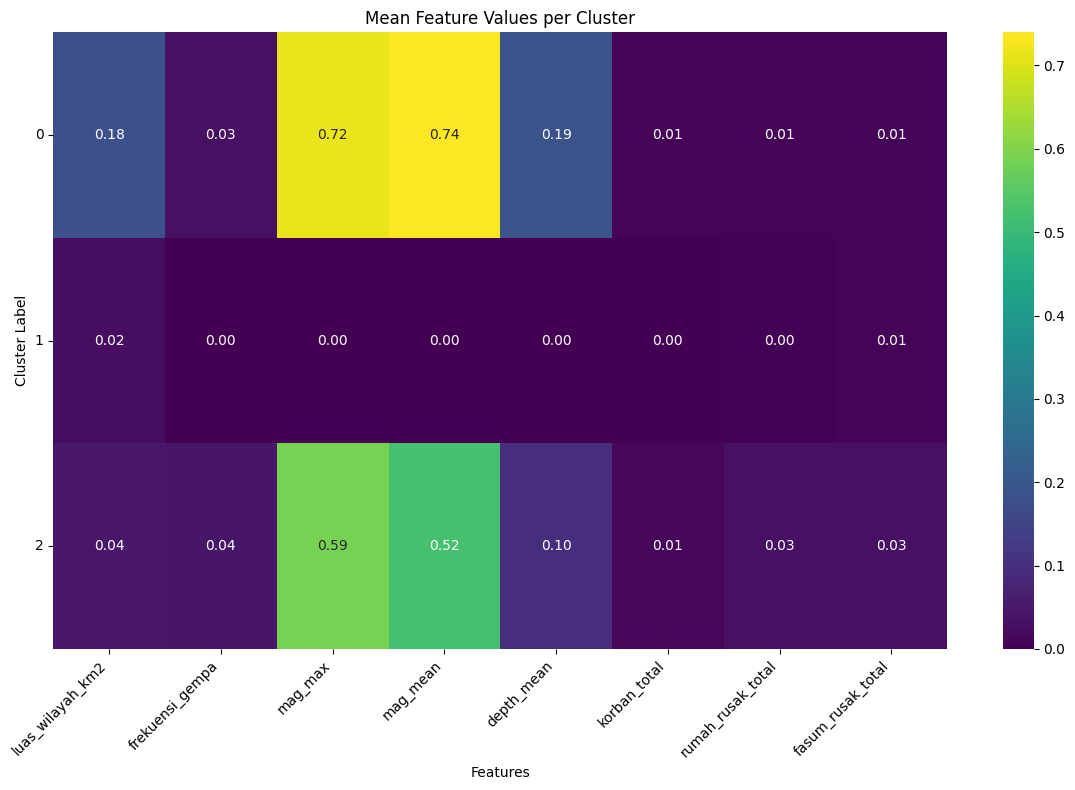

Heatmap of cluster characteristics displayed for visual interpretation.


In [153]:

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_characteristics_df, annot=True, cmap='viridis', fmt=".2f")
plt.title('Mean Feature Values per Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap of cluster characteristics displayed for visual interpretation.")

## Visualize Clusters


**Reasoning**:
To visualize the clusters, I will first reduce the dimensionality of the numerical data using Principal Component Analysis (PCA) to two components, making it suitable for a 2D scatter plot. I will then add these components to the `final_normalized_df`.



### PCA 

In [154]:
from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 2 principal components
pca = PCA(n_components=2)

# Fit and transform the numerical data for K-Medoids
# pca_components_array: NumPy array of the 2 principal components.
pca_components_array = pca.fit_transform(clustering_input_df)

# Create a DataFrame for the principal components (PC1 and PC2 only)
pca_df = pd.DataFrame(data=pca_components_array, columns=['PC1', 'PC2'])

# pca_result_df: DataFrame containing identifiers and only the PCA components for separate viewing.
pca_result_df = pd.concat([
    final_processed_df[['id_kabupaten', 'nama_kabupaten']].reset_index(drop=True),
    pca_df.reset_index(drop=True)
], axis=1)

# Add the principal components to the final_processed_df (for full data integration).
# Ensure that the index aligns correctly if final_processed_df was not reindexed
final_processed_df['PC1'] = pca_df['PC1']
final_processed_df['PC2'] = pca_df['PC2']

print("Data reduced to 2 principal components and added to final_processed_df.")
print("PCA Results (identifiers + PC1, PC2 only):")
display(pca_result_df.head())

Data reduced to 2 principal components and added to final_processed_df.
PCA Results (identifiers + PC1, PC2 only):


,id_kabupaten,nama_kabupaten,PC1,PC2
0,IDN.1.2_1,AcehBarat,0.065649,-0.119941
1,IDN.1.1_1,AcehBaratDaya,-0.015012,-0.001355
2,IDN.1.3_1,AcehBesar,0.043095,-0.056498
3,IDN.1.4_1,AcehJaya,0.129089,-0.062990
4,IDN.1.5_1,AcehSelatan,0.018521,-0.086756


**Reasoning**:
To visualize the clusters in a 2D space, I will create a scatter plot using the two principal components (PC1 and PC2) and color the data points based on their assigned `cluster_label`.



In [155]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_label',
    data=final_processed_df,
    palette='viridis', # Choose a color palette
    s=100, # Marker size
    alpha=0.7 # Transparency
)
plt.title('K-Medoids Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

print("Scatter plot of clusters based on PCA components displayed.")

ValueError: Could not interpret value `cluster_label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x800 with 0 Axes>

In [ ]:
# To get the count of items in each cluster, use the original DataFrame:
cluster_counts = final_processed_df.groupby("cluster_label").size().rename("count")

# To get the mean of all features across all clusters (i.e., mean of the means), use:
cluster_summary = final_processed_df.groupby("cluster_label").mean(numeric_only=True)

# Exclude PCA columns from the summary for risk score calculation.
cluster_summary_no_pca = cluster_summary.drop(columns=["PC1", "PC2"], errors="ignore")

# risk_score: Mean of all numerical features (excluding PCA) for each cluster.
cluster_summary_no_pca["risk_score"] = cluster_summary_no_pca.mean(axis=1)

# Sort clusters by their risk_score to assign risk levels (Rendah, Sedang, Tinggi).
cluster_summary_no_pca = cluster_summary_no_pca.sort_values("risk_score")

print("Cluster summary with risk scores calculated (sorted by risk level):")
display(cluster_summary_no_pca)

# Assign risk levels robustly depending on number of clusters
n_clusters = len(cluster_summary_no_pca)
if n_clusters >= 3:
    cluster_summary_no_pca["risk_level"] = pd.qcut(cluster_summary_no_pca["risk_score"], q=3, labels=["Rendah", "Sedang", "Tinggi"])
elif n_clusters == 2:
    cluster_summary_no_pca["risk_level"] = pd.qcut(cluster_summary_no_pca["risk_score"], q=2, labels=["Rendah", "Tinggi"])
else:
    cluster_summary_no_pca["risk_level"] = ["Rendah"] * n_clusters

# Build a cluster info DataFrame (cluster_label, risk_score, risk_level, count)
cluster_info_df = cluster_summary_no_pca[["risk_score", "risk_level"]].reset_index().rename(columns={"index": "cluster_label"})
cluster_info_df = cluster_info_df.merge(cluster_counts.reset_index(), on="cluster_label", how="left").rename(columns={0: "count"})

print("Cluster info (risk score + level + counts):")
display(cluster_info_df)

# Build table of all kabupaten with cluster and risk info
kabupaten_cluster_table = final_processed_df[["id_kabupaten", "nama_kabupaten", "cluster_label"]].merge(cluster_info_df, on="cluster_label", how="left")
# Reorder columns for readability
kabupaten_cluster_table = kabupaten_cluster_table[["id_kabupaten", "nama_kabupaten", "cluster_label", "risk_score", "risk_level", "count"]]

print("Tabel lengkap: id_kabupaten, nama_kabupaten, cluster_label, risk_score, risk_level, cluster_count")
display(kabupaten_cluster_table.sort_values(["cluster_label", "id_kabupaten"]).reset_index(drop=True))


Cluster summary with risk scores calculated (sorted by risk level):


,luas_wilayah_km2,frekuensi_gempa,mag_max,mag_mean,depth_mean,korban_total,rumah_rusak_total,fasum_rusak_total,risk_score
cluster_label,,,,,,,,,
1,0.024260,0.000000,0.000000,0.000000,0.000000,0.001062,0.004764,0.006097,0.004523
2,0.044592,0.041402,0.589047,0.521014,0.095679,0.013344,0.031196,0.030823,0.170887
0,0.179433,0.030043,0.715755,0.739747,0.185183,0.005871,0.007050,0.009828,0.234114


Cluster info (risk score + level + counts):


,cluster_label,risk_score,risk_level,count
0,1,0.004523,Rendah,52
1,2,0.170887,Sedang,293
2,0,0.234114,Tinggi,157


Tabel lengkap: id_kabupaten, nama_kabupaten, cluster_label, risk_score, risk_level, cluster_count


,id_kabupaten,nama_kabupaten,cluster_label,risk_score,risk_level,count
0,IDN.1.22_1,Simeulue,0,0.234114,Tinggi,157
1,IDN.10.10_1,Jepara,0,0.234114,Tinggi,157
2,IDN.10.17_1,KotaSemarang,0,0.234114,Tinggi,157
3,IDN.10.29_1,Sragen,0,0.234114,Tinggi,157
4,IDN.11.18_1,Lamongan,0,0.234114,Tinggi,157
...,...,...,...,...,...,...
497,IDN.9.5_1,Bogor,2,0.170887,Sedang,293
498,IDN.9.6_1,Ciamis,2,0.170887,Sedang,293
499,IDN.9.7_1,Cianjur,2,0.170887,Sedang,293
500,IDN.9.8_1,Cimahi,2,0.170887,Sedang,293


### Merge Model Output with Risk Table

In [ ]:
# Merge risk info into final_processed_df (updates the DataFrame in-place)
final_processed_df = final_processed_df.merge(cluster_info_df[["cluster_label", "risk_score", "risk_level"]], on="cluster_label", how="left")

# Create a compact view with only identifiers + cluster + risk info
final_with_risk_df = final_processed_df[["id_kabupaten", "nama_kabupaten", "cluster_label", "risk_score", "risk_level"]].copy()

print("Displaying final_processed_df (head) and final_with_risk_df (head):")
display(final_processed_df.head())
display(final_with_risk_df.head())

# Keep final_with_risk_df available for downstream use
print("Final DataFrame with risk levels ready for use:")
display(final_with_risk_df)

Displaying final_processed_df (head) and final_with_risk_df (head):


,id_kabupaten,nama_kabupaten,luas_wilayah_km2,frekuensi_gempa,mag_max,mag_mean,depth_mean,korban_total,rumah_rusak_total,fasum_rusak_total,cluster_label,PC1,PC2,risk_score,risk_level
0,IDN.1.2_1,AcehBarat,0.063280,0.145007,0.695494,0.528401,0.031300,0.000000,0.000054,0.000000,2,0.065649,-0.119941,0.170887,Sedang
1,IDN.1.1_1,AcehBaratDaya,0.042475,0.022344,0.575891,0.524423,0.087906,0.000000,0.000114,0.000000,2,-0.015012,-0.001355,0.170887,Sedang
2,IDN.1.3_1,AcehBesar,0.065579,0.054720,0.640945,0.547892,0.049984,0.000000,0.000000,0.000000,2,0.043095,-0.056498,0.170887,Sedang
3,IDN.1.4_1,AcehJaya,0.087150,0.042408,0.743394,0.555719,0.091837,0.000000,0.000000,0.000194,2,0.129089,-0.062990,0.170887,Sedang
4,IDN.1.5_1,AcehSelatan,0.094703,0.062927,0.640668,0.500170,0.064964,0.000156,0.018286,0.062791,2,0.018521,-0.086756,0.170887,Sedang


,id_kabupaten,nama_kabupaten,cluster_label,risk_score,risk_level
0,IDN.1.2_1,AcehBarat,2,0.170887,Sedang
1,IDN.1.1_1,AcehBaratDaya,2,0.170887,Sedang
2,IDN.1.3_1,AcehBesar,2,0.170887,Sedang
3,IDN.1.4_1,AcehJaya,2,0.170887,Sedang
4,IDN.1.5_1,AcehSelatan,2,0.170887,Sedang


Final DataFrame with risk levels ready for use:


,id_kabupaten,nama_kabupaten,cluster_label,risk_score,risk_level
0,IDN.1.2_1,AcehBarat,2,0.170887,Sedang
1,IDN.1.1_1,AcehBaratDaya,2,0.170887,Sedang
2,IDN.1.3_1,AcehBesar,2,0.170887,Sedang
3,IDN.1.4_1,AcehJaya,2,0.170887,Sedang
4,IDN.1.5_1,AcehSelatan,2,0.170887,Sedang
...,...,...,...,...,...
497,IDN.33.1_1,Bantul,2,0.170887,Sedang
498,IDN.33.2_1,GunungKidul,2,0.170887,Sedang
499,IDN.33.3_1,KotaYogyakarta,1,0.004523,Rendah
500,IDN.33.4_1,KulonProgo,2,0.170887,Sedang


# Result Model Gempa K-Medoids

In [ ]:
def save_model(model, scaler, path="app/models/model.pkl"):
    with open(path, "wb") as f:
        pickle.dump({
            "model": model,
            "scaler": scaler
        }, f)

    print("Model saved successfully.")